# Manuscript figures
This notebook contains code to plot all figures in the MetaHQ manuscript.

Author: Parker Hicks <br>
Date: 2026-01-17 <br>
Last updated: 2026-05-13 by Parker Hicks

In [ ]:
import re
from collections import defaultdict
from math import ceil
from pathlib import Path
from typing import Any, Literal

import marimo as mo
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
import seaborn as sns
from bson import BSON
from matplotlib import ticker
from upsetplot import UpSet, from_contents

In [ ]:
def load_bson(file: Path | str, **kwargs) -> dict[str, Any]:
    """Load dictionary from compressed bson."""
    with open(file, "rb") as bf:
        return BSON(bf.read()).decode(**kwargs)

def load_txt(file: Path | str, **kwargs) -> list[str]:
    """Load txt file."""
    with open(file, "r", **kwargs) as f:
        return [line.strip() for line in f.readlines()]

In [ ]:
# constants
ANNOTATIONS_DIR = Path("data/processed")  # MetaHQ database v1.1.0
ATTRIBUTES = ["tissue", "disease", "sex", "age"]

METADATA_DIR = Path("data/metadata")
PLATFORMS_FILE = METADATA_DIR / "technologies.parquet"

RESULTS_DIR: Path = Path("results")
UNIQUE_PROPAGATED_TERMS: Path = RESULTS_DIR / "unique_propagated_tissue_disease_terms.txt"
OVERLAP_RESULTS = list(RESULTS_DIR.glob("overlap*"))

FIGURES_DIR: Path = Path("figures")

# plotting
COLORS = {'tissue': 'steelblue', 'disease': 'coral', 'sex': 'mediumseagreen', 'age': 'mediumpurple'}
FMT = "png"
OVERLAP_ORDER = ["tissue", "disease", "sex", "age"]
OVERLAP_CMAP = "Blues"
PMI_CMAP = "vlag"

In [ ]:
""# load the databases
sample_db = load_bson(ANNOTATIONS_DIR / "combined__level-sample.bson")
series_db = load_bson(ANNOTATIONS_DIR / "combined__level-series.bson")

print("Number of entries in MetaHQ:")
print(f"Samples: {len(sample_db)}")
print(f"Studies: {len(series_db)}")

Number of entries in MetaHQ:
Samples: 190175
Studies: 19723


# Plot total annotations for each attribute

In [ ]:
def plot_total_anno(
    data: dict,
    attributes: list[str],
    ylabel: str,
    figsize: tuple[int, int]=(5,5),
    save: bool=False,
    outfile: str | Path | None = None,
    dpi: int = 600,
    order: list[str] | None = None,
    verbose: bool = False,
):
    """Plot the total number of entries with each attribute annotation."""
    total = {attribute: 0 for attribute in attributes}
    for anno in data.values():
        for attribute in attributes:
            if attribute in anno:
                total[attribute] += 1

    df = pl.DataFrame(
        {"attribute": list(total.keys()), "count": list(total.values())}
    )

    colors = {k.capitalize(): v for k,v in COLORS.items()}

    # capitalize attribute names
    df = df.with_columns(pl.col("attribute").str.to_titlecase().alias("attribute"))

    plt.figure(figsize=figsize)
    ax = sns.barplot(
        df, x="attribute",
        y="count",
        hue="attribute",
        palette=colors,
        order=order,
    )

    # x-axis
    plt.xlabel("")
    ax.tick_params("x", rotation=45)

    # y-axis
    plt.ylabel(ylabel)
    ax.get_yaxis().set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

    sns.despine(right=True, top=True)
    plt.tight_layout()

    if save and isinstance(outfile, str):
        plt.savefig(outfile, dpi=dpi)

    plt.show()

def plot_total_anno_sample_and_study(
    sample_data: dict,
    study_data: dict,
    attributes: list[str],
    ylabel: str,
    figsize: tuple[int, int]=(5,5),
    save: bool=False,
    outfile: str | Path | None = None,
    dpi: int = 600,
    verbose: bool = False,
    titles: list[str] | None = None,
    order: list[str] | None = None,
    ylim_scale: int = 1,
):
    """Plot the total number of entries with each attribute annotation."""
    colors = {k.capitalize(): v for k,v in COLORS.items()}

    dfs = []
    # count attribute anntotations
    for data in [sample_data, study_data]:
        total = {attribute: 0 for attribute in attributes}
        for anno in data.values():
            for attribute in attributes:
                if attribute in anno:
                    total[attribute] += 1

        df = pl.DataFrame(
                {"attribute": list(total.keys()), "count": list(total.values())}
        )

        # convert attributes to uppercase
        df = (
            df
                .with_columns(
                    pl.col("attribute").str.to_titlecase().alias("attribute")
                )
        )
        dfs.append(df)

    # figure with subplots
    fig, axes = plt.subplots(1, 2, figsize=figsize, sharey=True)

    for idx, (df, ax) in enumerate(zip(dfs, axes)):
        sns.barplot(
            df, 
            y="attribute",
            x="count",
            hue="attribute", 
            palette=colors, 
            ax=ax,
            legend=False,
            order=order,
        )

        ax.set_xlabel(ylabel)
        ax.get_xaxis().set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))
        ax.tick_params("x", rotation=30)

        # sample ticks
        if idx == 0:
            ax.set_xticks([50000, 150000])

        # study ticks
        if idx == 1:
            ax.set_xticks([5000, 15000])

        # y-axis (now shows categories)
        ax.set_ylabel("" if idx > 0 else "")  # Only show ylabel on leftmost plot

        # Add title if provided
        if titles and idx < len(titles):
            ax.set_title(titles[idx])

        sns.despine(right=True, top=True, ax=ax)

    plt.tight_layout()

    if save and isinstance(outfile, (str, Path)):
        plt.savefig(outfile, dpi=dpi)

    plt.show()

## Samples

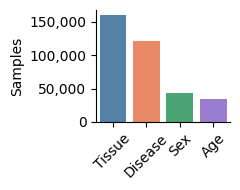

In [ ]:
plot_total_anno(
    sample_db,
    attributes=["disease", "tissue", "sex", "age"],
    ylabel="Samples",
    figsize=(2.5,2),
    save=True,
    outfile="figures/attribute_sample_count.svg",
    dpi=1000,
    order=["Tissue", "Disease", "Sex", "Age"],
)

## Studies

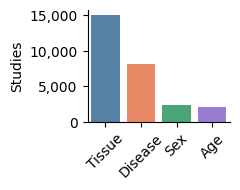

In [ ]:
plot_total_anno(
    series_db,
    attributes=["disease", "tissue", "sex", "age"],
    ylabel="Studies",
    figsize=(2.5,2),
    save=True,
    outfile="figures/attribute_study_count.svg",
    dpi=1000,
    order=["Tissue", "Disease", "Sex", "Age"],
)

## Both

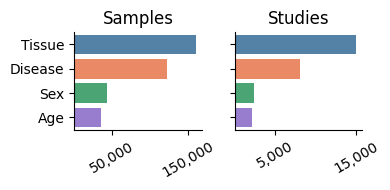

In [ ]:
plot_total_anno_sample_and_study(
    sample_db,
    series_db,
    attributes=["disease", "tissue", "sex", "age"],
    ylabel="",
    figsize=(4, 2),
    titles=["Samples", "Studies"],
    save=True,
    outfile="figures/attribute_sample_and_study_count.svg",
    dpi=1000,
    order=["Tissue", "Disease", "Sex", "Age"],
    ylim_scale=1,
)

# Upset plot

### Format data for upset plot

In [ ]:
def count_entries_per_attribute(records: dict[str, list[str]], title: str):
    """For each attribute, count the number of
    entries (samples or studies) that have at least 
    one annotation to that attribute.
    """
        # show number of samples annotated to any attribute
    print(title)
    print("================")
    for attribute, entries in records.items():
        print(f"{attribute.capitalize()}: {len(entries)}")
    print("================\n")


def record_entries_per_attribute(
    database: dict,
    attributes: list[str],
    tech: Literal["rnaseq", "microarray"],
    verbose: bool = False,
    title: str = "Records",
) -> dict[str, list[str]]:
    """Record the samples that 

    Used as input to `upset_plot()`

    """
    platforms = (
        pl.scan_parquet(PLATFORMS_FILE)
            .filter(pl.col("technology") == tech)
            .select("id")
            .collect()
            .to_series()
    ) 
    records = {attribute: [] for attribute in attributes}
    for entry, anno in database.items():

        platform_ok = False
        if "platform" not in anno["accession_ids"]:
            print(anno)

        for platform in anno["accession_ids"]["platform"].split("||"):
            if platform in platforms:
                platform_ok = True
                break

        if not platform_ok:
            continue

        for attribute in records:
            if attribute in anno:
                records[attribute].append(entry)

    if verbose:
        count_entries_per_attribute(records, title)

    return records

In [ ]:
def upset_plot(
    records: dict[str, list[str]],
    title: str | None = None,
    save: bool = False,
    outfile: str | None = None,
    dpi: int=500,
    ylim: int | None = None
):
    df = from_contents(
        {attribute.capitalize(): records[attribute] for attribute in records}
    )
    ax_dict = UpSet(df).plot()

    if isinstance(title, str):
        plt.title(title, fontsize=12, fontweight="bold")

    if isinstance(ylim, int):
        plt.ylim(0, ylim)

    plt.tight_layout()

    if save and isinstance(outfile, str):
        plt.savefig(outfile, dpi=dpi)

    plt.show()

In [ ]:
# get attribute sample/study counts


# ========== Sample ============
sample_records_microarray = record_entries_per_attribute(
    sample_db, ATTRIBUTES, verbose=True, title="Sample Records (microarray):", tech="microarray"
)
sample_records_rnaseq = record_entries_per_attribute(
    sample_db, ATTRIBUTES, verbose=True, title="Sample Records (rnaseq):", tech="rnaseq"
)

# ========== Study ============
study_records_microarray = record_entries_per_attribute(
    series_db, ATTRIBUTES, verbose=True, title="Study Records (microarray):", tech="microarray"
)
study_records_rnaseq = record_entries_per_attribute(
    series_db, ATTRIBUTES, verbose=True, title="Study Records (rnaseq):", tech="rnaseq"
)

Sample Records (microarray):
Tissue: 106634
Disease: 75627
Sex: 33978
Age: 26042

Sample Records (rnaseq):
Tissue: 53138
Disease: 46233
Sex: 9170
Age: 8938

Study Records (microarray):
Tissue: 7354
Disease: 3811
Sex: 1172
Age: 815

Study Records (rnaseq):
Tissue: 6225
Disease: 3733
Sex: 857
Age: 1034



/Users/parkerhicks/Desktop/Code/meta-hq/.venv/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/parkerhicks/Desktop/Code/meta-hq/.venv/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original o

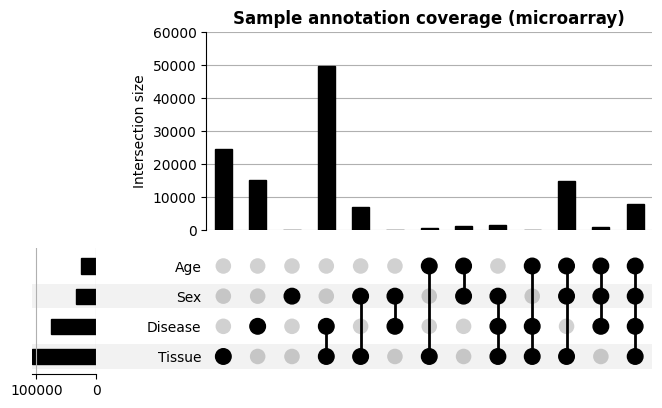

/Users/parkerhicks/Desktop/Code/meta-hq/.venv/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/parkerhicks/Desktop/Code/meta-hq/.venv/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original o

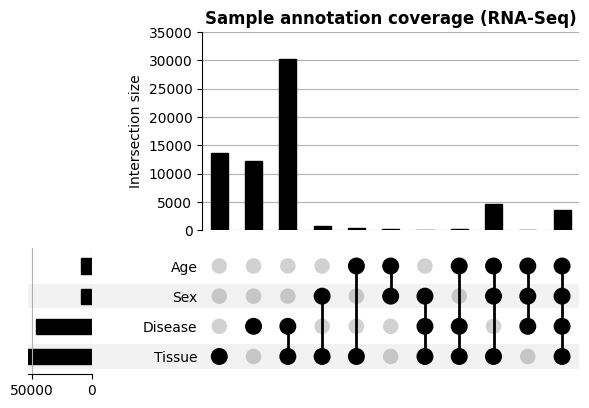

/Users/parkerhicks/Desktop/Code/meta-hq/.venv/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/parkerhicks/Desktop/Code/meta-hq/.venv/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original o

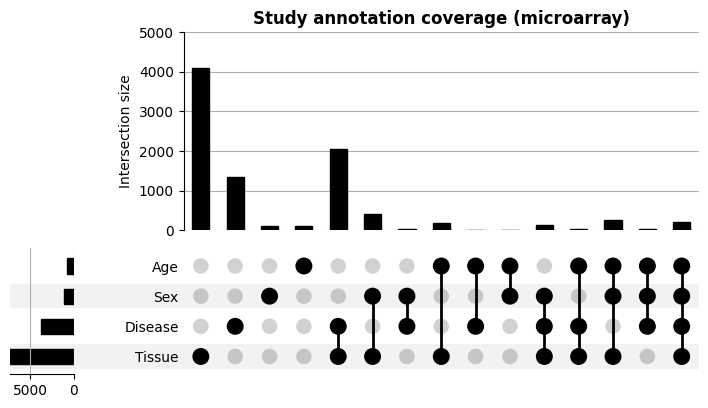

/Users/parkerhicks/Desktop/Code/meta-hq/.venv/lib/python3.12/site-packages/upsetplot/data.py:385: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df.fillna(False, inplace=True)
/Users/parkerhicks/Desktop/Code/meta-hq/.venv/lib/python3.12/site-packages/upsetplot/plotting.py:795: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original o

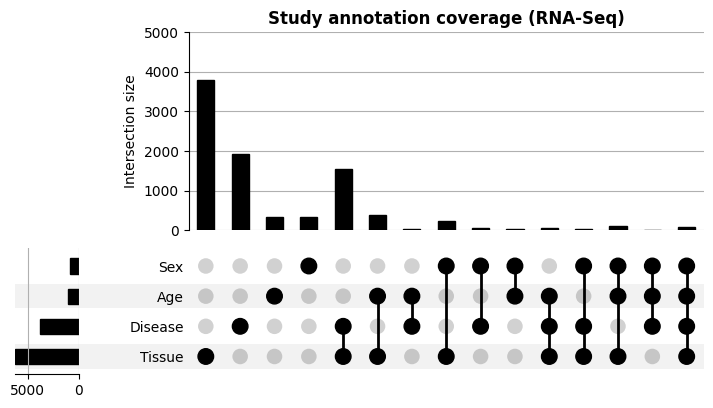

In [ ]:
# upset plots
# Note: there is a bug in the Upsetplot package where pandas v3 raises errors. They're working on a fix: https://github.com/jnothman/UpSetPlot/issues/303, but it is not yet resolved. Use pandas <3.0.0.

# ========== Sample ============
upset_plot(
    sample_records_microarray,
    title="Sample annotation coverage (microarray)",
    save=True,
    outfile=f"figures/attribute_upset_plot__level-sample__tech-microarray.{FMT}",
    dpi=500,
    ylim=60_000,
)
upset_plot(
    sample_records_rnaseq,
    title="Sample annotation coverage (RNA-Seq)",
    save=True,
    outfile=f"figures/attribute_upset_plot__level-sample__tech-rnaseq.{FMT}",
    dpi=500,
    ylim=35_000,
)

# ========== Study ============
upset_plot(
    study_records_microarray,
    title="Study annotation coverage (microarray)",
    save=True,
    outfile=f"figures/attribute_upset_plot__level-study__tech-microarray.{FMT}",
    dpi=500,
    ylim=5_000,
)
# ========== Study ============
upset_plot(
    study_records_rnaseq,
    title="Study annotation coverage (RNA-Seq)",
    save=True,
    outfile=f"figures/attribute_upset_plot__level-study__tech-rnaseq.{FMT}",
    dpi=500,
    ylim=5_000
)

# Get source counts

In [ ]:
def acceptable_platform_sample(entry, ok_platforms):
    if "platform" in entry["accession_ids"]:
        gpl = entry["accession_ids"]["platform"]
        if gpl in ok_platforms:
            return True

    return False

def acceptable_platform_study(entry, ok_platforms):
    if "platform" in entry["accession_ids"]:
        gpls = entry["accession_ids"]["platform"].split("||")
        if len(set(gpls) & set(ok_platforms)) > 0:
            return True

    return False


def get_source_counts(
    database: dict,
    level: Literal["sample", "study"],
    platforms: pl.DataFrame,
):
    platform_mapping_funcs = {"sample": acceptable_platform_sample, "study": acceptable_platform_study}
    is_acceptable_platform = platform_mapping_funcs[level]

    UNDESIRED = [
        "na",
        "",
        "NA",
        "none",
        None,
        "not annotated",
    ]

    # Collect all unique sources across all attributes first
    all_sources = set()
    for id_, data in database.items():
        for attribute in ["tissue", "disease", "sex", "age"]:
            if attribute in data:
                all_sources.update(data[attribute].keys())

    # Store results for each technology
    all_results = []
    attributes = ["tissue", "disease", "sex", "age"]

    # Count sources for each attribute across all GSM IDs, separated by technology
    for technology in platforms["technology"].unique():
        ok_platforms = platforms.filter(pl.col("technology") == technology)["id"].to_list()

        tissue_sources = defaultdict(int)
        disease_sources = defaultdict(int)
        sex_sources = defaultdict(int)
        age_sources = defaultdict(int)

        for id_, data in database.items():

            if not is_acceptable_platform(data, ok_platforms):
                continue

            # Count tissue sources
            if "tissue" in data:
                for source, source_data in data["tissue"].items():
                    if "id" in source_data:
                        if source_data["id"] not in UNDESIRED:
                            tissue_sources[source] += 1

            # Count disease sources
            if "disease" in data:
                for source, source_data in data["disease"].items():
                    if "id" in source_data:
                        if source_data["id"] not in UNDESIRED:
                            disease_sources[source] += 1

            # Count sex sources
            if "sex" in data:
                for source, source_data in data["sex"].items():
                    if "id" in source_data:
                        if source_data["id"] not in UNDESIRED:
                            sex_sources[source] += 1

            # Count age sources
            if "age" in data:
                for source, source_data in data["age"].items():
                    if "id" in source_data:
                        if source_data["id"] not in UNDESIRED:
                            age_sources[source] += 1

        # Create dataframes for this technology, ensuring all sources appear
        for attribute, source_dict in [
            ("tissue", tissue_sources),
            ("disease", disease_sources),
            ("sex", sex_sources),
            ("age", age_sources)
        ]:
            df = pl.DataFrame(
                {
                    "technology": [technology for _ in all_sources],
                    "attribute": [attribute for _ in all_sources],
                    "source": list(all_sources),
                    "count": [source_dict.get(source, 0) for source in all_sources],
                }
            )
            all_results.append(df)

    return pl.concat(all_results)

In [ ]:
platforms = pl.read_parquet(PLATFORMS_FILE)

sample_source_counts = get_source_counts(sample_db, "sample", platforms)
study_source_counts = get_source_counts(series_db, "study", platforms)

# Plot source counts

In [ ]:
def plot_source_counts_by_attribute(
    df: pl.DataFrame,
    ylabel: str,
    attributes: list[str],
    figsize: tuple[int, int]=(10, 8),
    title: str = "",
    save: bool=False,
    outfile: str | None = None,
    dpi: int = 500,
    ylim_scale: int = 1,
    verbose: bool = False,
):
    import matplotlib.colors as mcolors
    from matplotlib.patches import Patch

    TECHNOLOGY_COLORS = {
        "microarray": "dimgrey",
        "rnaseq": "lightgrey",
    }

    def lighten_color(color, amount=0.5):
        try:
            c = mcolors.to_rgb(color)
        except ValueError:
            c = mcolors.to_rgb(mcolors.cnames[color])
        c = [(1 - amount) * comp + amount for comp in c]
        return c

    def get_tech_color(tech, base_color):
        if tech == "microarray":
            return base_color
        elif tech == "rnaseq":
            return lighten_color(base_color, amount=0.6)
        else:
            return base_color

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    axes = axes.flatten()

    technologies = df["technology"].unique().sort().to_list()
    all_sources = sorted(df["source"].unique().to_list())

    for idx, attribute in enumerate(attributes):
        df_filtered = df.filter(pl.col("attribute") == attribute)

        df_plot = df_filtered.with_columns(
            pl.col("source").cast(pl.Enum(all_sources))
        ).sort("source")

        dark_color = COLORS[attribute]
        palette = {tech: get_tech_color(tech, dark_color) for tech in technologies}

        sns.barplot(
            data=df_plot.to_pandas(),
            y="count",
            x="source",
            hue="technology",
            ax=axes[idx],
            palette=palette,
        )

        if axes[idx].get_legend():
            axes[idx].get_legend().remove()

        axes[idx].tick_params(axis='x', rotation=90)
        for label in axes[idx].get_xticklabels():
            label.set_ha('center')
        axes[idx].set_title(f'{attribute.capitalize()}', fontsize=14)
        axes[idx].set_xlabel('', fontsize=12)
        axes[idx].set_ylabel(ylabel, fontsize=12)
        axes[idx].set_ylim(0, (ceil(df_plot['count'].max() / ylim_scale) * ylim_scale))
        axes[idx].grid(axis='y', alpha=0.3)

        axes[idx].yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f'{int(x):,}'))

        sns.despine(ax=axes[idx], top=True, right=True, left=True)

        if verbose:
            print(f"\n{attribute.capitalize()} annotations by technology:")
            for tech in df_filtered["technology"].unique():
                tech_total = df_filtered.filter(pl.col("technology") == tech)["count"].sum()
                print(f"  {tech}: {tech_total:,}")

    legend_elements = [
        Patch(
            facecolor=get_tech_color(tech, "dimgrey"),
            label=tech
        )
        for tech in technologies
    ]

    fig.legend(handles=legend_elements, title='Technology', loc='upper right',
               bbox_to_anchor=(0.98, 0.86), fontsize=10)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()

    if save and isinstance(outfile, str):
        plt.savefig(outfile, dpi=dpi, bbox_inches="tight")
    plt.show()

## Sample

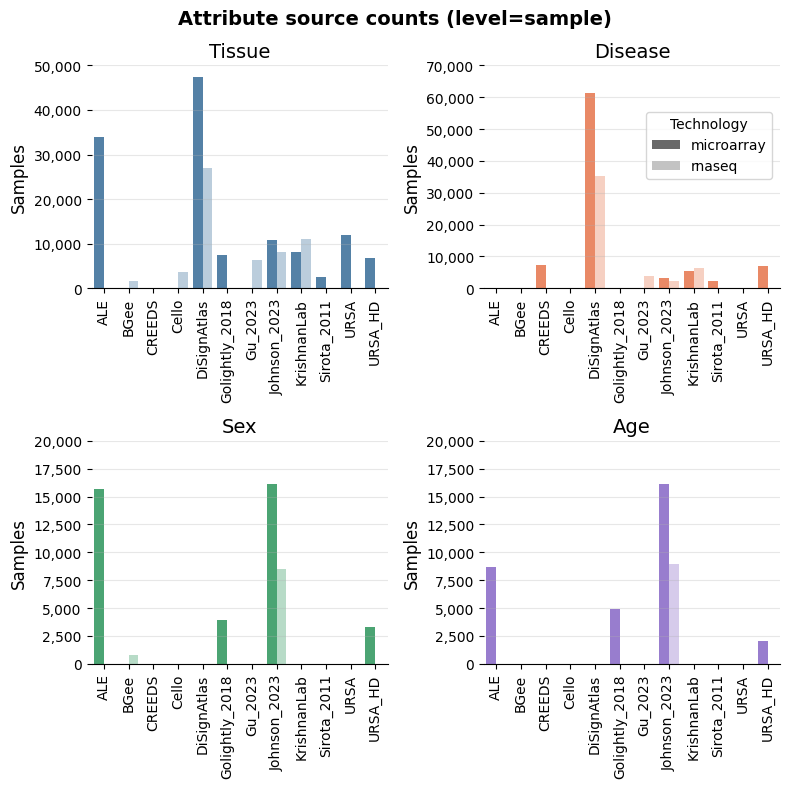

In [ ]:
plot_source_counts_by_attribute(
    sample_source_counts,
    "Samples",
    ATTRIBUTES,
    figsize=(8,8),
    title="Attribute source counts (level=sample)",
    save=True,
    outfile=f"figures/source_counts_by_attribute__level-sample__tech-all.{FMT}",
    dpi=500,
    ylim_scale=10_000,
)

## Study

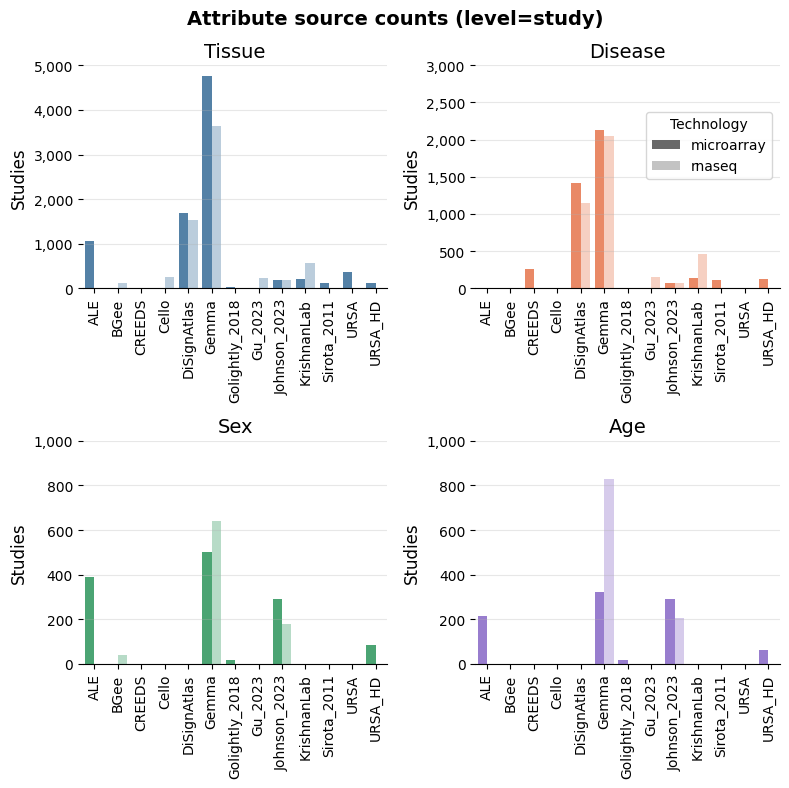

In [ ]:
plot_source_counts_by_attribute(
    study_source_counts,
    "Studies",
    ATTRIBUTES,
    figsize=(8,8),
    title="Attribute source counts (level=study)",
    save=True,
    outfile=f"figures/source_counts_by_attribute__level-study__tech-all.{FMT}",
    dpi=500,
    ylim_scale=1000,
)

## Number of available tissues and diseases

### Direct annotations

In [ ]:
def get_direct_annotations(data: dict, attributes: list[str] = ["tissue", "disease"]):
    direct_annotations = {attribute: set() for attribute in attributes}
    for anno in data.values():
        for attribute in attributes:
            if attribute not in anno:
                continue
            for source in anno[attribute]:
                for entry in anno[attribute][source]["id"].split("|"):
                    direct_annotations[attribute].add(entry)

    return direct_annotations

In [ ]:
sample_tissue_disease_direct_annotations = get_direct_annotations(sample_db)
study_tissue_disease_direct_annotations = get_direct_annotations(series_db)

In [ ]:
unique_tissues = sample_tissue_disease_direct_annotations["tissue"] & study_tissue_disease_direct_annotations["tissue"]
unique_diseases = (sample_tissue_disease_direct_annotations["disease"] & study_tissue_disease_direct_annotations["disease"])

print(f"Number of unique tissues that are directly annotated: {len(unique_tissues)}")
print(f"Number of unique diseases that are directly annotated: {len(unique_diseases)}")

Number of unique tissues that are directly annotated: 667
Number of unique diseases that are directly annotated: 937


### Propagated annotations

In [ ]:
unique_propagated_terms = load_txt(UNIQUE_PROPAGATED_TERMS)

for attribute in ["tissue", "disease"]:

    terms = set()
    for term in unique_propagated_terms:
        if (attribute == "tissue") and (term.startswith("UBERON") or term.startswith("CL")):
            terms.add(term)
        if (attribute == "disease") and (term.startswith("MONDO")):
            terms.add(term)

    print(f"Number of unique {attribute}s in propagated annotations: {len(terms)}")

Number of unique tissues in propagated annotations: 2463
Number of unique diseases in propagated annotations: 2741


# Annotation overlap across sources

In [ ]:
def match_pattern(text: str, pattern: str) -> str:
    match = re.search(pattern, text)
    if match:
        return match.group(1)
    else:
        return ""


def get_overlap_results(
    dir: Path,
    overlap_type: str,
    level: Literal["sample", "series"],
    attribute_pattern: str = r"attribute-(tissue|disease|sex|age)",
    level_pattern: str = r"level-(sample|series)",
    pmi: bool = False,
    separator="\t",
    **pmi_kwargs,
) -> dict[str, pl.DataFrame]:
    results: dict[str, pl.DataFrame] = {}

    files = list(RESULTS_DIR.glob(f"{overlap_type}*"))

    for file in files:

        file_level = match_pattern(file.stem, level_pattern)
        if file_level != level:
            continue

        attribute = match_pattern(file.stem, attribute_pattern)
        df = pl.read_csv(file, separator=separator)
        if pmi:
            values = pmi_from_cooccurrence(df.to_numpy(), **pmi_kwargs)
            df = pl.DataFrame(values, schema=df.columns)

        results[attribute] = df

    if len(results) == 0:
        print("No files found that met conditions:")
        print(f"Directory: {dir}")
        print(f"Overlap type: {overlap_type}")
        print(f"Level: {level}")
        print(f"Attribute pattern: {attribute_pattern}")
        print(f"Level pattern: {level_pattern}")
        print(f"Files: {files}")
        raise RuntimeError()

    return results

In [ ]:
def pmi_from_cooccurrence(x: np.typing.NDArray, method: Literal["positive", "norm"] | None = None):
    """Compute pointwise mutual information for all pairs from a 
    symmetric co-occurrence matrix.

    Arguments:
        x (NDArray):
            2D array-like, symmetric count matrix.
        positive (bool):
            If True, return PPMI.
        method (Literal['positive', 'norm'] | None):
            Compute ppmi or npmi.

    Returns:
        (NDArray): square 2D numpy array of PMI values
    """
    x = np.array(x, dtype=float)


    total = x.sum()


    col_sums = x.sum(axis=1)

    joint = x / total
    outer_marginals = np.outer(col_sums, col_sums) / (total ** 2)

    with np.errstate(divide='ignore', invalid='ignore'):
        pmi = np.where(
            joint > 0,
            np.log2(joint / outer_marginals),
            -np.inf
        )

    if method == "positive":
        pmi = np.maximum(pmi, 0)

    if method == "norm":
        with np.errstate(divide='ignore', invalid='ignore'):
            pmi = np.where(
                joint > 0,
                pmi / -np.log2(joint),
                np.nan
            )

    np.fill_diagonal(pmi, np.nan)
    return pmi

In [ ]:
def plot_overlap_heatmap(
    overlap_results: dict[str, pl.DataFrame],
    subplot_shape: tuple[int, int] = (2, 2),
    figsize_per_plot: tuple[int, int] = (5, 5),
    order: list[str] | None = None,
    save: bool = False,
    outfile: Path | str | None = None,
    vmax_percentile: float | int | None = None,
    **heatmap_kwargs,
):
    nrows, ncols = subplot_shape
    fig, axes = plt.subplots(
        nrows,
        ncols,
        figsize=(figsize_per_plot[0] * ncols, figsize_per_plot[1] * nrows),
    )

    if isinstance(axes, np.ndarray):
        axes_flat = axes.flatten()
    else:
        axes_flat = [axes]

    if isinstance(order, list):
        overlap_results = {k: overlap_results[k] for k in order}

    for ax, (group_name, df) in zip(axes_flat, overlap_results.items()):
        df = (
            df.with_columns(pl.Series("source", df.columns))
            .to_pandas()
            .set_index("source", drop=True)
        )

        if "vmax" not in heatmap_kwargs and (isinstance(vmax_percentile, (int, float))):
            vmax = np.percentile(df.to_numpy(), vmax_percentile)
            sns.heatmap(df, ax=ax, vmax=vmax, **heatmap_kwargs)
        else:
            sns.heatmap(df, ax=ax, **heatmap_kwargs)

        ax.set_title(group_name.capitalize())
        xticks = ax.get_xticklabels()
        ax.set_xticklabels(labels=xticks, rotation=45, ha='right', rotation_mode='anchor')

    for ax in axes_flat[len(overlap_results):]:
        ax.axis("off")

    plt.tight_layout()

    if save and isinstance(outfile, (str, Path)):
        plt.savefig(outfile, dpi=400)

    plt.show()

## Sample

### Absolute counts

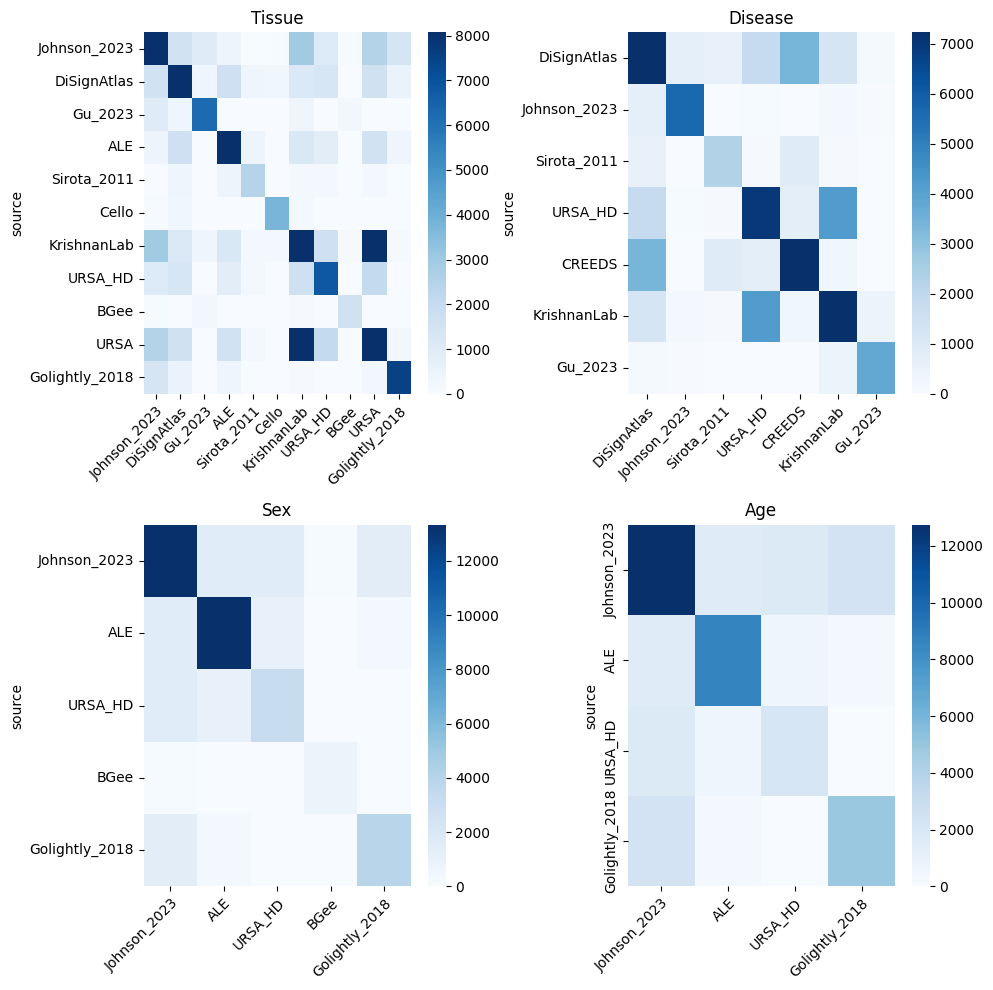

In [ ]:
sample_overlap_count = get_overlap_results(RESULTS_DIR, overlap_type="overlap_count", level="sample")
plot_overlap_heatmap(
    sample_overlap_count,
    order=OVERLAP_ORDER,
    cmap=OVERLAP_CMAP,
    vmax_percentile=95,
    save=True,
    outfile=FIGURES_DIR / "overlap__level-sample__metric-counts.png"
)

### Percent overlap

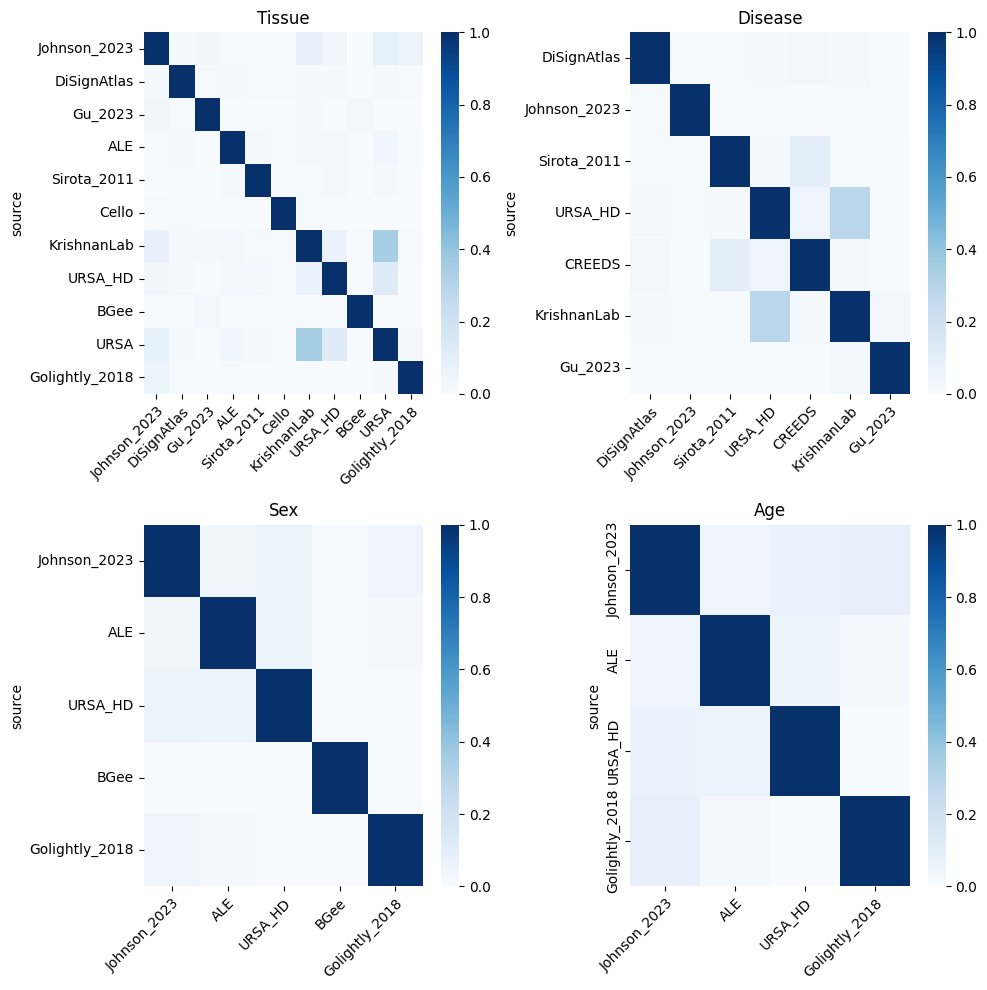

In [ ]:
sample_overlap_percent = get_overlap_results(RESULTS_DIR, overlap_type="overlap_percent", level="sample")
plot_overlap_heatmap(
    sample_overlap_percent,
    order=OVERLAP_ORDER,
    cmap=OVERLAP_CMAP,
    save=True,
    outfile=FIGURES_DIR / "overlap__level-sample__metric-percent.png",
    )

### Normalized PMI

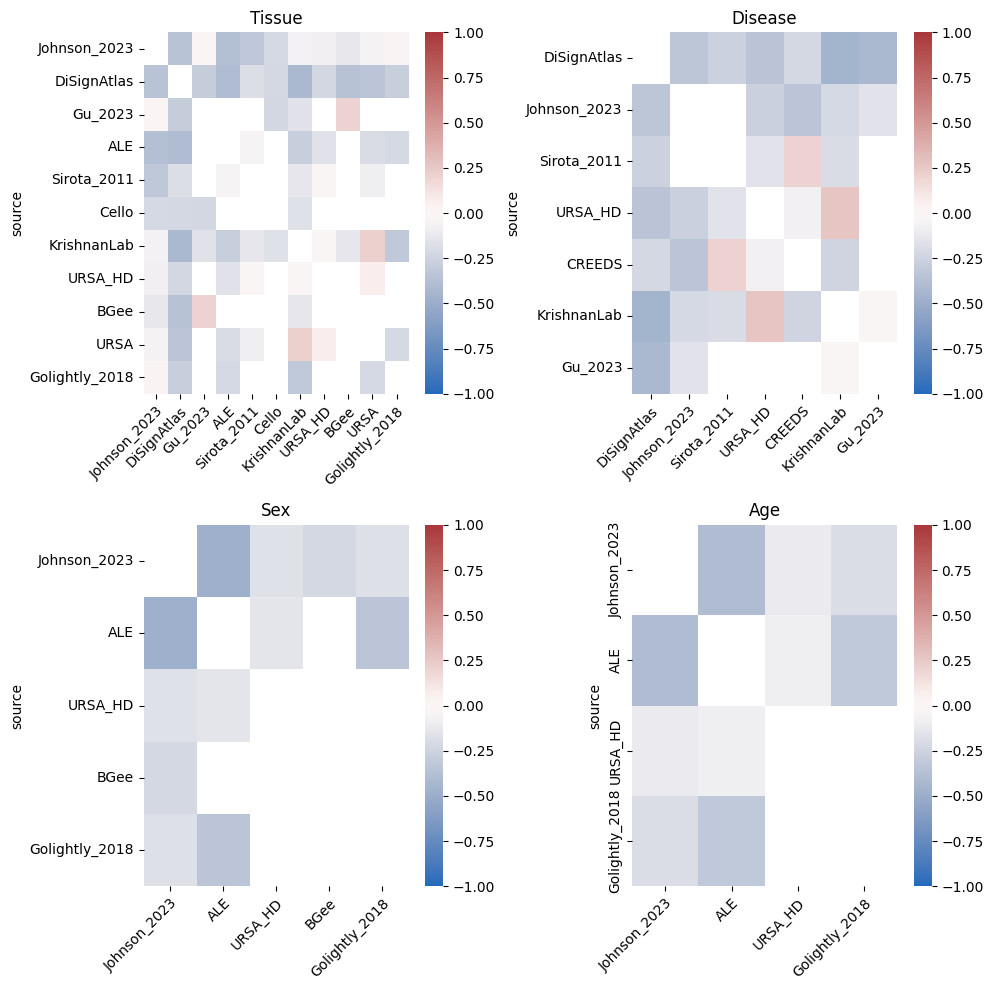

In [ ]:
sample_overlap_pmi = get_overlap_results(
    RESULTS_DIR,
    overlap_type="overlap_count",
    level="sample",
    pmi=True,
    method="norm",
)
plot_overlap_heatmap(
    sample_overlap_pmi,
    order=OVERLAP_ORDER,
    cmap=PMI_CMAP,
    vmax=1,
    vmin=-1,
    save=True,
    outfile=FIGURES_DIR / "overlap__level-sample__metric-pmi.png",
)

## Series

### Absolute counts

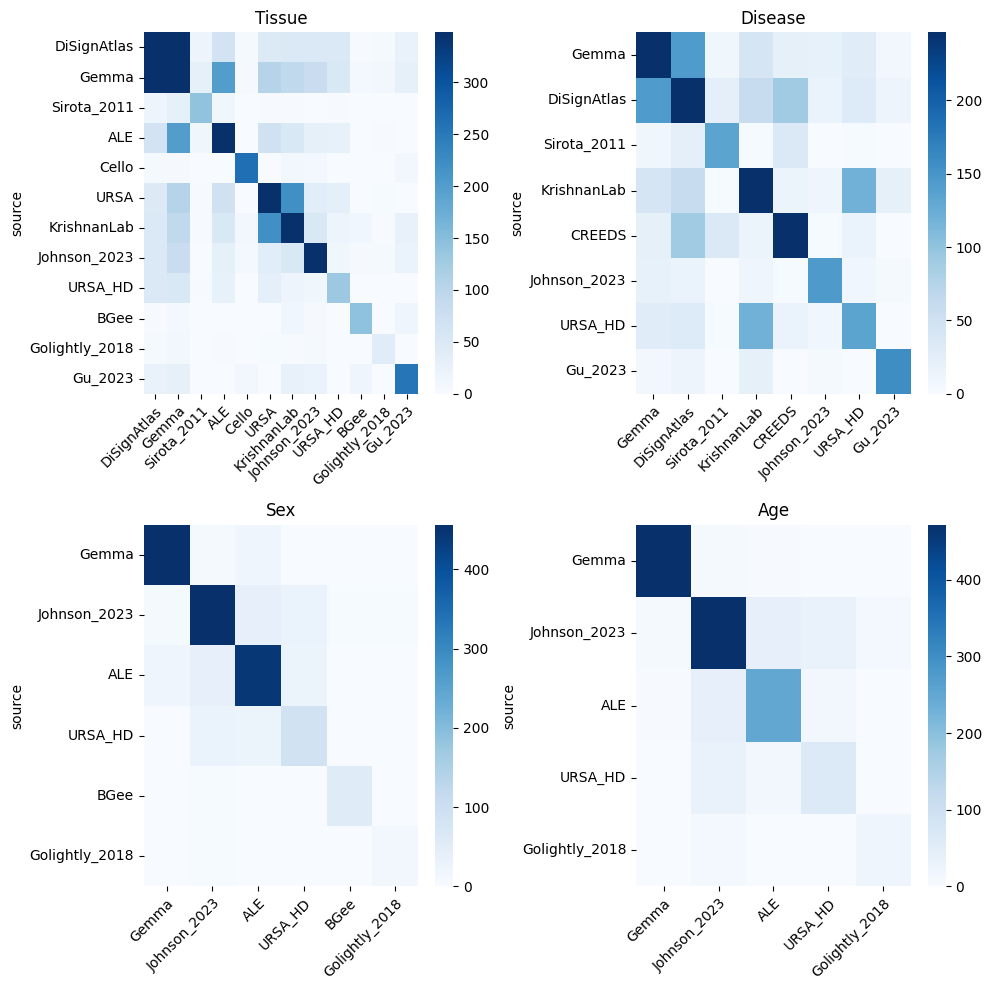

In [ ]:
series_overlap_count = get_overlap_results(
    RESULTS_DIR, overlap_type="overlap_count", level="series"
)
plot_overlap_heatmap(
    series_overlap_count,
    order=OVERLAP_ORDER,
    cmap=OVERLAP_CMAP, 
    vmax_percentile=95,
    save=True,
    outfile=FIGURES_DIR / "overlap__level-series__metric-counts.png",
)

### Percent overlap

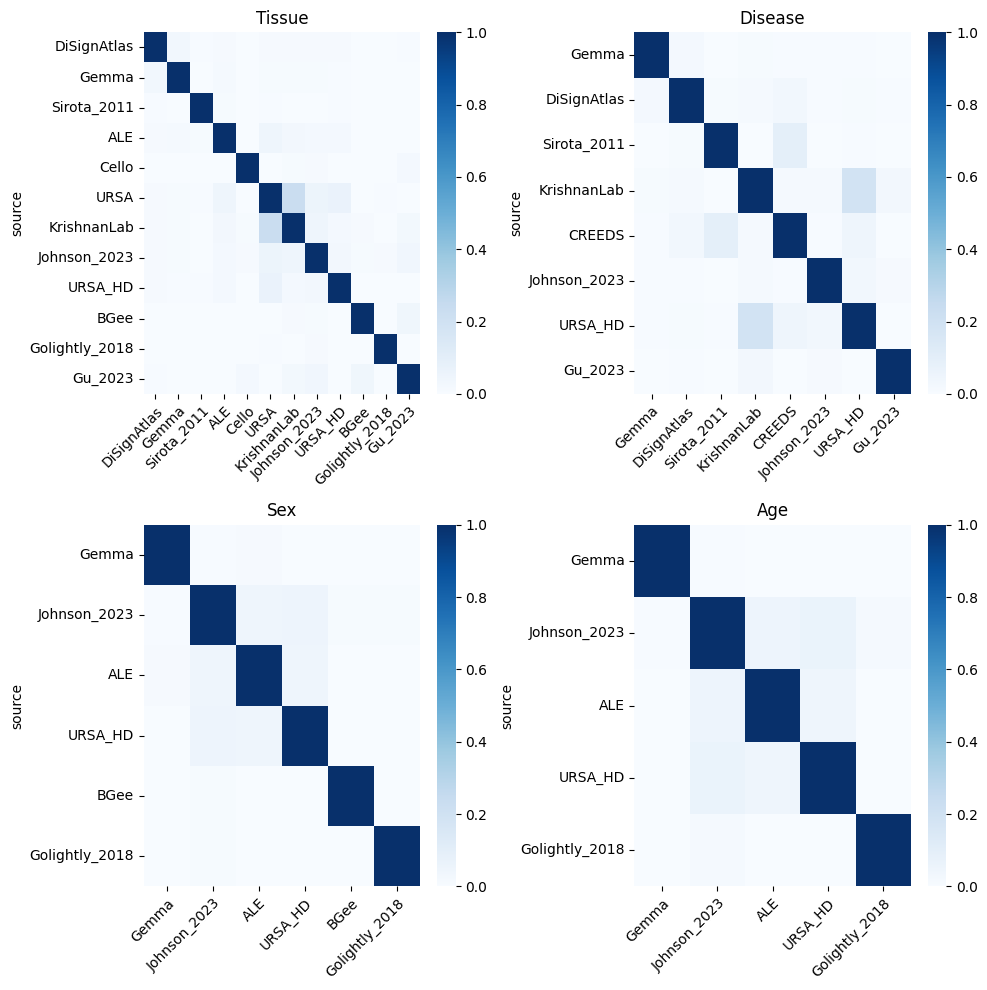

In [ ]:
series_overlap_percent = get_overlap_results(
    RESULTS_DIR, overlap_type="overlap_percent", level="series"
)
plot_overlap_heatmap(
    series_overlap_percent,
    order=OVERLAP_ORDER,
    cmap=OVERLAP_CMAP,
    save=True,
    outfile=FIGURES_DIR / "overlap__level-series__metric-percent.png",
)

### PMI

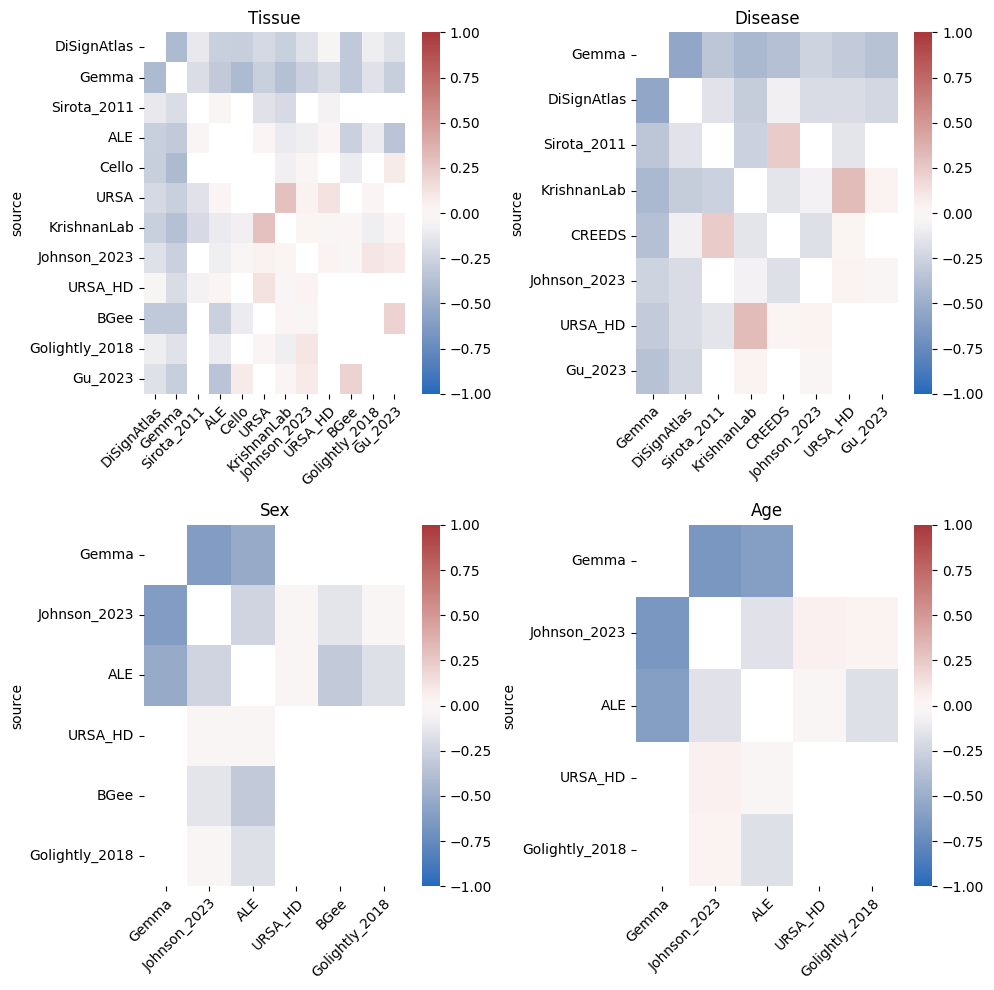

In [ ]:
series_overlap_pmi = get_overlap_results(
    RESULTS_DIR,
    overlap_type="overlap_count",
    level="series",
    pmi=True,
    method="norm"
)
plot_overlap_heatmap(
    series_overlap_pmi,
    order=OVERLAP_ORDER,
    cmap=PMI_CMAP,
    vmax=1,
    vmin=-1,
    save=True,
    outfile=FIGURES_DIR / "overlap__level-series__metric-pmi.png",
)